In [2]:
import pandas as pd

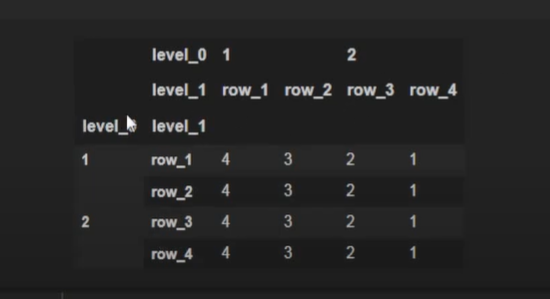

## Создание мультииндекса из массива

In [5]:
array = [[1, 1, 2, 2], ['row_1', 'row_2', 'row_3', 'row_4']]
array

[[1, 1, 2, 2], ['row_1', 'row_2', 'row_3', 'row_4']]

In [7]:
multi_array = pd.MultiIndex.from_arrays(array, names = ['level_0', 'level_1'])

multi_array

MultiIndex([(1, 'row_1'),
            (1, 'row_2'),
            (2, 'row_3'),
            (2, 'row_4')],
           names=['level_0', 'level_1'])

In [11]:
df = pd.DataFrame([[4, 3, 2, 1],
                  [4, 3, 2, 1],
                  [4, 3, 2, 1],
                  [4, 3, 2, 1]], 
                  index = multi_array
                 )
df

0  1  2  3
level_0 level_1            
1       row_1    4  3  2  1
        row_2    4  3  2  1
2       row_3    4  3  2  1
        row_4    4  3  2  1

In [13]:
df = pd.DataFrame([[4, 3, 2, 1],
                  [4, 3, 2, 1],
                  [4, 3, 2, 1],
                  [4, 3, 2, 1]], 
                  columns = multi_array
                 )
df

level_0     1           2      
level_1 row_1 row_2 row_3 row_4
0           4     3     2     1
1           4     3     2     1
2           4     3     2     1
3           4     3     2     1

## Создание мультииндекса методом from_product

In [20]:
level_0 = ['row_1', 'row_2']
level_1 = [1, 2, 3]

multi_product = pd.MultiIndex.from_product([level_0, level_1], names = ['level_0', 'level_1'])
multi_product

MultiIndex([('row_1', 1),
            ('row_1', 2),
            ('row_1', 3),
            ('row_2', 1),
            ('row_2', 2),
            ('row_2', 3)],
           names=['level_0', 'level_1'])

In [121]:
df = pd.DataFrame({'col_1':[5, 6, 6, 3, 7, 6],
                  'col_2':[3, 2, 6, 3, 7, 4],
                  'col_3':[5, 6, 3, 3, 4, 5],
                  'col_4':[5, 6, 7, 8, 7, 3]},
                  index = multi_product
                 )
df

col_1  col_2  col_3  col_4
level_0 level_1                            
row_1   1            5      3      5      5
        2            6      2      6      6
        3            6      6      3      7
row_2   1            3      3      3      8
        2            7      7      4      7
        3            6      4      5      3

## Создание мультииндекса из кортежей

In [33]:
t = [(1, 'row_1'), (1, 'row_2'), (1, 'row_3'), (2, 'row_1'), (2, 'row_2'), (2, 'row_3')]

multi_tuple = pd.MultiIndex.from_tuples(t, names = ['level_0', 'level_1'])

multi_tuple

MultiIndex([(1, 'row_1'),
            (1, 'row_2'),
            (1, 'row_3'),
            (2, 'row_1'),
            (2, 'row_2'),
            (2, 'row_3')],
           names=['level_0', 'level_1'])

In [123]:
df = pd.DataFrame({'col_1':[5, 6, 6, 3, 7, 6],
                  'col_2':[3, 2, 6, 3, 7, 4],
                  'col_3':[5, 6, 3, 3, 4, 5],
                  'col_4':[5, 6, 7, 8, 7, 3]},
                  index = multi_tuple
                 )
df

col_1  col_2  col_3  col_4
level_0 new_level_1                            
1       row_1            5      3      5      5
        row_2            6      2      6      6
        row_3            6      6      3      7
2       row_1            3      3      3      8
        row_2            7      7      4      7
        row_3            6      4      5      3

## Реальный пример

In [38]:
rows = [('Asia', 'CN'),
        ('Asia', 'VN'),
        ('Europe', 'GB'),
        ('Europe', 'RU'),
        ('S. America', 'AR'),
        ('S. America', 'BO'),
        ('Africa', 'ZA')]
rows

[('Asia', 'CN'),
 ('Asia', 'VN'),
 ('Europe', 'GB'),
 ('Europe', 'RU'),
 ('S. America', 'AR'),
 ('S. America', 'BO'),
 ('Africa', 'ZA')]

In [40]:
cols = [('names', 'country'),
        ('names', 'capital'),
        ('data', 'population'),
        ('data', 'area'),
        ('data', 'sea')]
cols

[('names', 'country'),
 ('names', 'capital'),
 ('data', 'population'),
 ('data', 'area'),
 ('data', 'sea')]

In [44]:
custom_multindex = pd.MultiIndex.from_tuples(rows, names = ['region', 'code'])
custom_multindex

MultiIndex([(      'Asia', 'CN'),
            (      'Asia', 'VN'),
            (    'Europe', 'GB'),
            (    'Europe', 'RU'),
            ('S. America', 'AR'),
            ('S. America', 'BO'),
            (    'Africa', 'ZA')],
           names=['region', 'code'])

In [46]:
custom_multicols = pd.MultiIndex.from_tuples(cols)
custom_multicols

MultiIndex([('names',    'country'),
            ('names',    'capital'),
            ( 'data', 'population'),
            ( 'data',       'area'),
            ( 'data',        'sea')],
           )

In [ ]:
# Наконец остается передать эти индексы в атрибуты index и columns и вывести результат
countries.index = custom_multindex
countries.columns = custom_multicols
 
countries

 ## Свойства и методы мультииндекса

In [51]:
df.index

MultiIndex([(1, 'row_1'),
            (1, 'row_2'),
            (1, 'row_3'),
            (2, 'row_1'),
            (2, 'row_2'),
            (2, 'row_3')],
           names=['level_0', 'level_1'])

In [53]:
df.columns

Index(['col_1', 'col_2', 'col_3', 'col_4'], dtype='object')

In [55]:
df.index.nlevels # число уровней мультииндекса

2

In [59]:
df.index.levshape # кортеж с длиной каждого уровня

(2, 3)

In [61]:
df.index.names #  получить имена уровней

FrozenList(['level_0', 'level_1'])

In [66]:
df.index.names = ['new_level_0', 'new_level_1']
df.index.names

FrozenList(['new_level_0', 'new_level_1'])

In [72]:
# изменение имен 
df.index.set_names(['level_0', 'level_1'],
                  inplace = True
                  )
df.index.names

FrozenList(['level_0', 'level_1'])

In [78]:
#изменение имени одного из уровней 
df.index.set_names('new_level_1',
                   level = 1,
                   inplace = True
                  )
df.index.names

FrozenList(['level_0', 'new_level_1'])

In [80]:
df.index.levels

FrozenList([[1, 2], ['row_1', 'row_2', 'row_3']])

In [85]:
multi_product

MultiIndex([('row_1', 1),
            ('row_1', 2),
            ('row_1', 3),
            ('row_2', 1),
            ('row_2', 2),
            ('row_2', 3)],
           names=['level_0', 'level_1'])

In [87]:
# замена мультииндекса
df.index = multi_product
df.index

MultiIndex([('row_1', 1),
            ('row_1', 2),
            ('row_1', 3),
            ('row_2', 1),
            ('row_2', 2),
            ('row_2', 3)],
           names=['level_0', 'level_1'])

In [91]:
new_index = df.index.set_levels([[4, 5, 6], ['q', 'w', 'r', 't', 'p']])
print(new_index)
print(new_index.levels)

MultiIndex([(4, 'q'),
            (4, 'w'),
            (4, 'r'),
            (5, 'q'),
            (5, 'w'),
            (5, 'r')],
           names=['level_0', 'level_1'])
[[4, 5, 6], ['q', 'w', 'r', 't', 'p']]


In [93]:
new_index = df.index.set_levels(['q', 'w', 'r', 't', 'p'], level = 0)
print(new_index)
print(new_index.levels)

MultiIndex([('q', 1),
            ('q', 2),
            ('q', 3),
            ('w', 1),
            ('w', 2),
            ('w', 3)],
           names=['level_0', 'level_1'])
[['q', 'w', 'r', 't', 'p'], [1, 2, 3]]


In [119]:
# Сброс уровней мультииндекса
new_df = df.reset_index()
new_df

,index,level_1,level_0,col_1,col_2,col_3,col_4
0,0,1,row_1,5,3,5,5
1,1,2,row_1,6,2,6,6
2,2,3,row_1,6,6,3,7
3,3,1,row_2,3,3,3,8
4,4,2,row_2,7,7,4,7
5,5,3,row_2,6,4,5,3


In [115]:
df

,level_1,level_0,col_1,col_2,col_3,col_4
0,1,row_1,5,3,5,5
1,2,row_1,6,2,6,6
2,3,row_1,6,6,3,7
3,1,row_2,3,3,3,8
4,2,row_2,7,7,4,7
5,3,row_2,6,4,5,3


In [125]:
df.reset_index(['level_0'],
              inplace = True
              )
df

,level_0,col_1,col_2,col_3,col_4
new_level_1,,,,,
row_1,1,5,3,5,5
row_2,1,6,2,6,6
row_3,1,6,6,3,7
row_1,2,3,3,3,8
row_2,2,7,7,4,7
row_3,2,6,4,5,3


In [127]:
df.index = multi_product
df

level_0  col_1  col_2  col_3  col_4
level_0 level_1                                     
row_1   1              1      5      3      5      5
        2              1      6      2      6      6
        3              1      6      6      3      7
row_2   1              2      3      3      3      8
        2              2      7      7      4      7
        3              2      6      4      5      3

In [133]:
#удаление уровня
new_index = df.index.droplevel()
print(df.index)
print(new_index)

MultiIndex([('row_1', 1),
            ('row_1', 2),
            ('row_1', 3),
            ('row_2', 1),
            ('row_2', 2),
            ('row_2', 3)],
           names=['level_0', 'level_1'])
Index([1, 2, 3, 1, 2, 3], dtype='int64', name='level_1')


In [135]:
new_index = df.index.droplevel(level = 1)
print(df.index)
print(new_index)

MultiIndex([('row_1', 1),
            ('row_1', 2),
            ('row_1', 3),
            ('row_2', 1),
            ('row_2', 2),
            ('row_2', 3)],
           names=['level_0', 'level_1'])
Index(['row_1', 'row_1', 'row_1', 'row_2', 'row_2', 'row_2'], dtype='object', name='level_0')


In [137]:
new_index = df.index.droplevel(['level_1'])
print(df.index)
print(new_index)

MultiIndex([('row_1', 1),
            ('row_1', 2),
            ('row_1', 3),
            ('row_2', 1),
            ('row_2', 2),
            ('row_2', 3)],
           names=['level_0', 'level_1'])
Index(['row_1', 'row_1', 'row_1', 'row_2', 'row_2', 'row_2'], dtype='object', name='level_0')
